In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import scipp as sc
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
import inspect

In [26]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

d = np.load(base / "data" / "kinisi_rw_data_1.npz")

cov = d["cov"]

msd = d["msd"]


In [27]:
timestep = msd[0, :, 0]

no = msd[0, :, 3]

dimensionality = 3

D_true = 1.0


In [28]:
n = no.shape[0]

ana= np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        ana[i, j] = 8 * dimensionality**2 * D_true**2 * timestep[i]**2 / (dimensionality * no[j])
        ana[j, i] = ana[i, j]


ana_vals = np.linalg.eigvalsh(ana)


print("analytical lambda_min", ana_vals[0], "lambda_max", ana_vals[-1])

analytical lambda_min 0.0030026716890643435 lambda_max 86416.95935575094


In [29]:
def eigdecomp(m):
    vals, vecs = np.linalg.eigh(m)
    
    return vals, vecs

In [30]:
def rebuild(vals, vecs):
    return (vecs * vals) @ vecs.T

In [31]:
def method_raw(m):
    return m

In [32]:
def method_mineig(m, cond_max=1e16):
    vals, vecs = eigdecomp(m)

    floor = vals[-1] / cond_max

    vals = np.where(vals < floor, floor, vals)
    
    return rebuild(vals, vecs)


In [33]:
def method_ridge(m, cond_max=1e16):
    vals = np.linalg.eigvalsh(m)

    lmax, lmin = vals[-1], vals[0]

    delta = (lmax - cond_max * lmin) / (cond_max - 1)

    if delta <= 0:
        return m
    
    return m + delta * np.eye(m.shape[0])

In [34]:
def method_linear_shrink_oracle(m, target_ref):
    vals = np.linalg.eigvalsh(m)

    mu = np.trace(m) / m.shape[0]

    eye = np.eye(m.shape[0])

    alphas = np.linspace(0, 1, 51)

    best, best_err = None, np.inf

    for a in alphas:
        cand = (1 - a) * m + a * mu * eye
        err = np.linalg.norm(cand - target_ref)

        if err < best_err:
            best, best_err = cand, err
            
    return best

In [35]:
def method_nls_oracle(m, target_ref):
    vals, vecs = eigdecomp(m)
    lam_star = np.einsum('ij,jk,ki->i', vecs.T, target_ref, vecs)
    lam_star = np.maximum(lam_star, 1e-12)
    return rebuild(lam_star, vecs)

In [36]:
methods = {"raw": lambda m: method_raw(m),
           "kinisi mineig 1e16": lambda m: method_mineig(m, 1e16),
           "mineig 1e8": lambda m: method_mineig(m, 1e8),
           "mineig 1e4": lambda m: method_mineig(m, 1e4),
           "ridge 1e16": lambda m: method_ridge(m, 1e16),
           "linear shrink (oracle)": lambda m: method_linear_shrink_oracle(m, ana),
           "nls (oracle)": lambda m: method_nls_oracle(m, ana)}

In [37]:
times = timestep
y_design = np.column_stack([times, np.ones_like(times)])
x_design = np.column_stack([times, np.ones_like(times)])


def gls_D(m, y):
    try:
        w = np.linalg.solve(m, y_design)
        lhs = y_design.T @ w
        rhs = w.T @ y
        beta = np.linalg.solve(lhs, rhs)
        return beta[0] / (2 * dimensionality)
    except np.linalg.LinAlgError:
        return np.nan

In [38]:
n_test = 500

rows = {}

for name, fn in methods.items():
    lam_mins, frobs, Ds = [], [], []



    for k in tqdm(range(n_test), desc=name):
        m = fn(cov[k])
        lam_mins.append(np.linalg.eigvalsh(m)[0])
        frobs.append(np.linalg.norm(m - ana))
        Ds.append(gls_D(m, msd[k, :, 1]))




    lam_mins = np.array(lam_mins)


    Ds = np.array(Ds)


    rows[name] = {"frac_neg": np.mean(lam_mins < 0),
                  "median_lam_min": np.median(lam_mins),
                  "median_frob": np.median(frobs),
                  "D_bias": np.nanmedian(Ds) - D_true,
                  "D_spread": np.nanstd(Ds),
                  "D_rmse": np.sqrt(np.nanmean((Ds - D_true) ** 2))}



print(f"{'method':24s} {'neg%':>6s} {'lam_min':>10s} {'frob':>10s} {'D bias':>9s} {'D rmse':>9s}")



for name, r in rows.items():
    print(f"{name:24s} {100*r['frac_neg']:5.1f}% {r['median_lam_min']:10.4f} "
          f"{r['median_frob']:10.1f} {r['D_bias']:+9.4f} {r['D_rmse']:9.4f}")

nls (oracle): 100%|██████████| 500/500 [00:00<00:00, 529.44it/s]

method                     neg%    lam_min       frob    D bias    D rmse
raw                       82.2%   -23.2985    11445.0   -0.0024    0.0146
kinisi mineig 1e16         0.0%     0.0000    11444.3   -6.6075 1136.2048
mineig 1e8                 0.0%     0.0008    11444.3   -0.3508    3.9853
mineig 1e4                 0.0%     8.1655    11444.3   -0.0098    0.0555
ridge 1e16                 0.2%     0.0000    11697.3   -0.9609    3.0743
linear shrink (oracle)    65.8%    -9.6653     8195.2   -0.0001    0.0280
nls (oracle)               0.0%     0.0034     4217.1   -0.0023    0.0146


sweeps the condition-number cap from 1e2 to 1e16. Finds a valley at ~1e3.

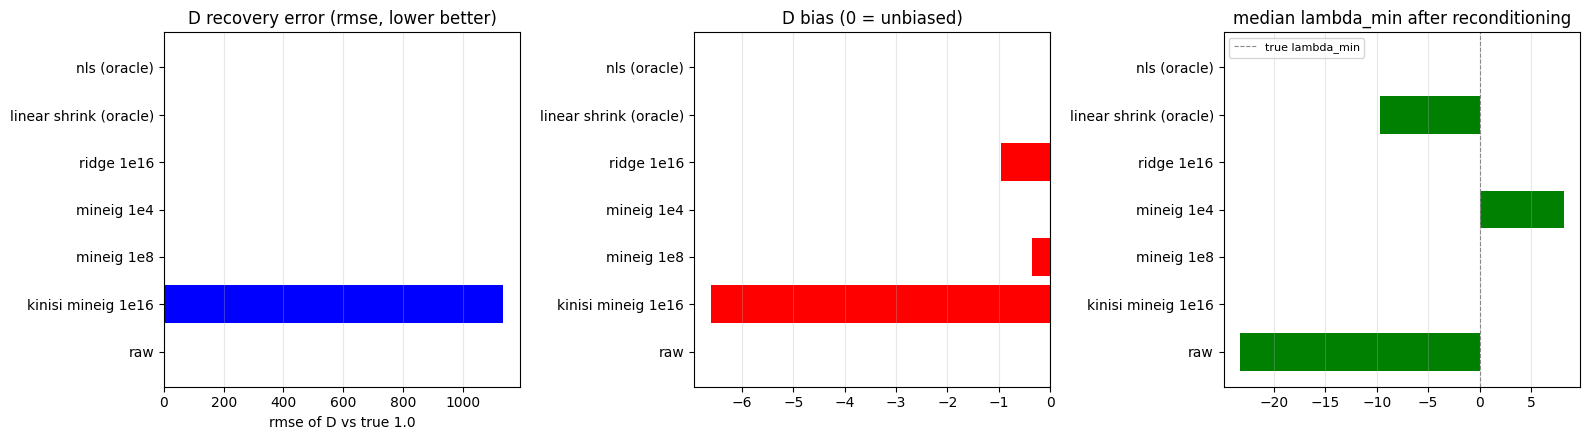

In [39]:
names = list(rows.keys())

rmses = [rows[k]["D_rmse"] for k in names]

biases = [rows[k]["D_bias"] for k in names]

lmins = [rows[k]["median_lam_min"] for k in names]






fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].barh(names, rmses, color="blue")

ax[0].set_title("D recovery error (rmse, lower better)")

ax[0].set_xlabel("rmse of D vs true 1.0")

ax[1].barh(names, biases, color="red")

ax[1].axvline(0, color="#888", linestyle="--", linewidth=0.8)

ax[1].set_title("D bias (0 = unbiased)")

ax[2].barh(names, lmins, color="green")

ax[2].axvline(ana_vals[0], color="#888", linestyle="--", linewidth=0.8, label="true lambda_min")

ax[2].set_title("median lambda_min after reconditioning")

ax[2].legend(fontsize=8)





for a in ax:
    a.grid(alpha=0.3, axis="x")

    
plt.tight_layout()
plt.show()

plots that sweep against raw and oracle reference lines.

adaptive per-matrix floor (floor = c·|λ_min|); sweeps c. Beats fixed caps.

In [40]:
kappas = np.logspace(2, 16, 29)

n_test = 500




eig_cache = []



for k in tqdm(range(n_test), desc="decompose"):
    vals, vecs = np.linalg.eigh(cov[k])
    eig_cache.append((vals, vecs))



def gls_D_from_eig(vals, vecs, y):
    vty = vecs.T @ y
    vtA = vecs.T @ y_design
    w = vtA / vals[:, None]
    lhs = vtA.T @ w
    rhs = w.T @ vty
    beta = np.linalg.solve(lhs, rhs)
    return beta[0] / (2 * dimensionality)



sweep = []

for kap in tqdm(kappas, desc="kappa sweep"):
    Ds, lmins = [], []

    for k in range(n_test):
        vals, vecs = eig_cache[k]
        floor = vals[-1] / kap
        fv = np.where(vals < floor, floor, vals)
        lmins.append(fv[0] if fv[0] < floor else floor if vals[0] < floor else vals[0])
        Ds.append(gls_D_from_eig(fv, vecs, msd[k, :, 1]))

    Ds = np.array(Ds)

    sweep.append({"kappa": kap,
                  "D_rmse": np.sqrt(np.nanmean((Ds - D_true) ** 2)),
                  "D_bias": np.nanmedian(Ds) - D_true,
                  "median_floor": np.median([eig_cache[k][0][-1] / kap for k in range(n_test)])})




for s in sweep:
    print(f"kappa {s['kappa']:.1e}   floor {s['median_floor']:.2e}   "
          f"D bias {s['D_bias']:+.4f}   D rmse {s['D_rmse']:.4f}")

kappa sweep: 100%|██████████| 29/29 [00:00<00:00, 161.44it/s]

kappa 1.0e+02   floor 8.17e+02   D bias -0.0106   D rmse 0.0521
kappa 3.2e+02   floor 2.58e+02   D bias -0.0106   D rmse 0.0451
kappa 1.0e+03   floor 8.17e+01   D bias -0.0097   D rmse 0.0407
kappa 3.2e+03   floor 2.58e+01   D bias -0.0093   D rmse 0.0420
kappa 1.0e+04   floor 8.17e+00   D bias -0.0098   D rmse 0.0555
kappa 3.2e+04   floor 2.58e+00   D bias -0.0112   D rmse 0.0909
kappa 1.0e+05   floor 8.17e-01   D bias -0.0131   D rmse 0.1616
kappa 3.2e+05   floor 2.58e-01   D bias -0.0164   D rmse 0.2917
kappa 1.0e+06   floor 8.17e-02   D bias -0.0207   D rmse 0.5239
kappa 3.2e+06   floor 2.58e-02   D bias -0.0286   D rmse 0.9280
kappa 1.0e+07   floor 8.17e-03   D bias -0.0539   D rmse 1.5952
kappa 3.2e+07   floor 2.58e-03   D bias -0.1276   D rmse 2.6115
kappa 1.0e+08   floor 8.17e-04   D bias -0.3508   D rmse 3.9853
kappa 3.2e+08   floor 2.58e-04   D bias -0.8578   D rmse 5.6474
kappa 1.0e+09   floor 8.17e-05   D bias -2.1950   D rmse 7.6715
kappa 3.2e+09   floor 2.58e-05   D bias 

plots the adaptive floor vs the best fixed cap.

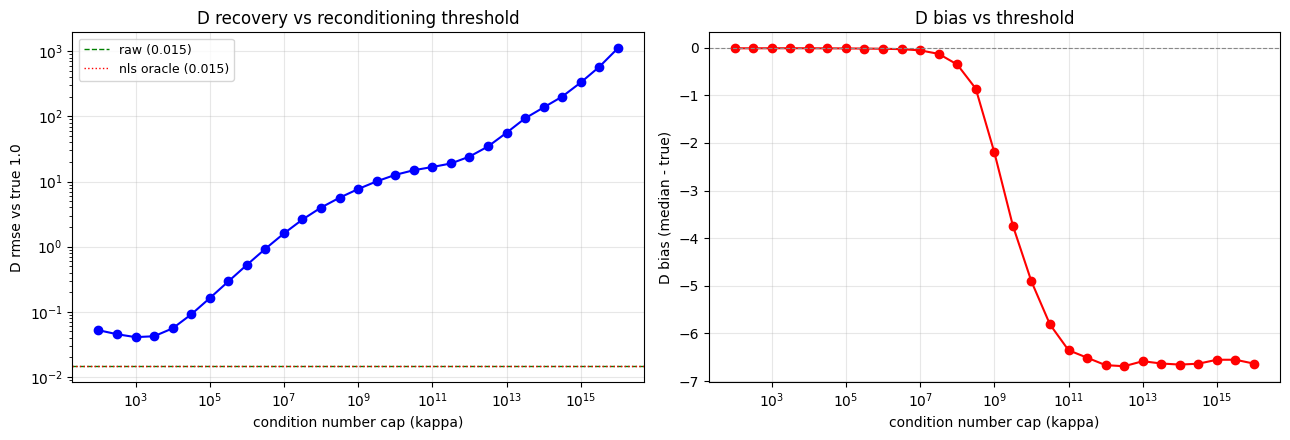


best kappa: 1.0e+03   rmse 0.0407   (raw 0.0146, nls oracle 0.0146)


In [41]:
kap_arr = np.array([s["kappa"] for s in sweep])

rmse_arr = np.array([s["D_rmse"] for s in sweep])

bias_arr = np.array([s["D_bias"] for s in sweep])


raw_rmse = rows["raw"]["D_rmse"]

nls_rmse = rows["nls (oracle)"]["D_rmse"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))




ax[0].plot(kap_arr, rmse_arr, marker="o", color="blue")
ax[0].axhline(raw_rmse, color="green", linestyle="--", linewidth=1, label=f"raw ({raw_rmse:.3f})")
ax[0].axhline(nls_rmse, color="red", linestyle=":", linewidth=1, label=f"nls oracle ({nls_rmse:.3f})")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("condition number cap (kappa)")
ax[0].set_ylabel("D rmse vs true 1.0")
ax[0].set_title("D recovery vs reconditioning threshold")
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)





ax[1].plot(kap_arr, bias_arr, marker="o", color="red")
ax[1].axhline(0, color="#888", linestyle="--", linewidth=0.8)
ax[1].set_xscale("log")
ax[1].set_xlabel("condition number cap (kappa)")
ax[1].set_ylabel("D bias (median - true)")
ax[1].set_title("D bias vs threshold")
ax[1].grid(alpha=0.3)



plt.tight_layout()
plt.show()



best = min(sweep, key=lambda s: s["D_rmse"])
print(f"\nbest kappa: {best['kappa']:.1e}   rmse {best['D_rmse']:.4f}   "
      f"(raw {raw_rmse:.4f}, nls oracle {nls_rmse:.4f})")

extends the c-sweep downward to find the turnover (optimum c = 0.2-0.3).

In [42]:
cs = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 50])


adaptive = []

for c in tqdm(cs, desc="c sweep"):
    Ds, altered, floors = [], 0, []

    for k in range(n_test):
        vals, vecs = eig_cache[k]

        if vals[0] < 0:
            floor = c * (-vals[0])
            fv = np.where(vals < floor, floor, vals)
            altered += 1
            floors.append(floor)

        else:
            fv = vals
        Ds.append(gls_D_from_eig(fv, vecs, msd[k, :, 1]))

    Ds = np.array(Ds)
    
    adaptive.append({"c": c,
                    "D_rmse": np.sqrt(np.nanmean((Ds - D_true) ** 2)),
                    "D_bias": np.nanmedian(Ds) - D_true,
                    "median_floor": np.median(floors),
                    "frac_altered": altered / n_test})



for s in adaptive:
    print(f"c {s['c']:5.1f}   median floor {s['median_floor']:8.2f}   "
          f"altered {100*s['frac_altered']:4.1f}%   D bias {s['D_bias']:+.4f}   D rmse {s['D_rmse']:.4f}")

c sweep: 100%|██████████| 10/10 [00:00<00:00, 167.17it/s]

c   0.5   median floor    18.80   altered 82.2%   D bias -0.0076   D rmse 0.0315
c   1.0   median floor    37.60   altered 82.2%   D bias -0.0069   D rmse 0.0332
c   2.0   median floor    75.20   altered 82.2%   D bias -0.0071   D rmse 0.0357
c   3.0   median floor   112.80   altered 82.2%   D bias -0.0072   D rmse 0.0376
c   5.0   median floor   188.00   altered 82.2%   D bias -0.0070   D rmse 0.0402
c   8.0   median floor   300.80   altered 82.2%   D bias -0.0069   D rmse 0.0429
c  12.0   median floor   451.20   altered 82.2%   D bias -0.0072   D rmse 0.0454
c  20.0   median floor   752.00   altered 82.2%   D bias -0.0080   D rmse 0.0486
c  30.0   median floor  1128.00   altered 82.2%   D bias -0.0084   D rmse 0.0511
c  50.0   median floor  1879.99   altered 82.2%   D bias -0.0084   D rmse 0.0542


setup for the real check (posterior model + flooring functions).

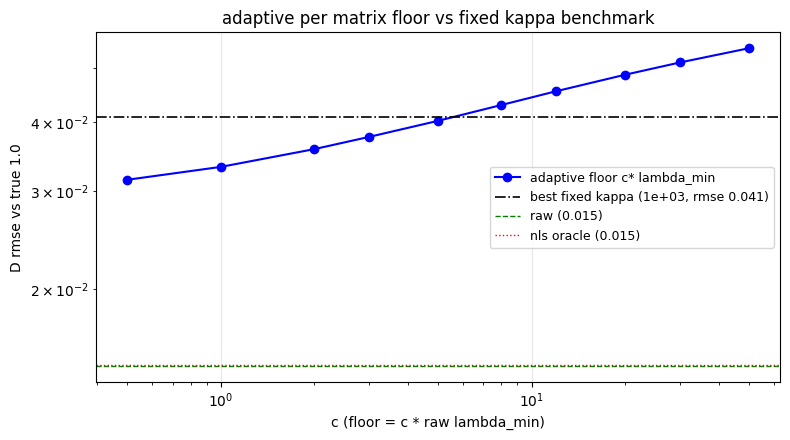


best c = 0.5   rmse 0.0315   vs best fixed kappa rmse 0.0407


In [43]:
c_arr = np.array([s["c"] for s in adaptive])

ad_rmse = np.array([s["D_rmse"] for s in adaptive])

best_fixed = min(sweep, key=lambda s: s["D_rmse"])




fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(c_arr, ad_rmse, marker="o", color="blue", label="adaptive floor c* lambda_min")

ax.axhline(best_fixed["D_rmse"], color="black", linestyle="-.", linewidth=1.2,
           label=f"best fixed kappa ({best_fixed['kappa']:.0e}, rmse {best_fixed['D_rmse']:.3f})")

ax.axhline(raw_rmse, color="green", linestyle="--", linewidth=1, label=f"raw ({raw_rmse:.3f})")

ax.axhline(nls_rmse, color="red", linestyle=":", linewidth=1, label=f"nls oracle ({nls_rmse:.3f})")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("c (floor = c * raw lambda_min)")

ax.set_ylabel("D rmse vs true 1.0")

ax.set_title("adaptive per matrix floor vs fixed kappa benchmark")

ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


best_ad = min(adaptive, key=lambda s: s["D_rmse"])
print(f"\nbest c = {best_ad['c']}   rmse {best_ad['D_rmse']:.4f}   "
      f"vs best fixed kappa rmse {best_fixed['D_rmse']:.4f}")

setup for the real check (posterior model + flooring functions).

In [44]:
cs_low = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5])

for c in cs_low:
    Ds = []

    for k in range(n_test):
        vals, vecs = eig_cache[k]

        if vals[0] < 0:
            floor = c * (-vals[0])
            fv = np.where(vals < floor, floor, vals)

        else:
            fv = vals
        Ds.append(gls_D_from_eig(fv, vecs, msd[k, :, 1]))

    Ds = np.array(Ds)

    rmse = np.sqrt(np.nanmean((Ds - D_true) ** 2))

    bias = np.nanmedian(Ds) - D_true
    
    print(f"c {c:5.2f}   D bias {bias:+.4f}   D rmse {rmse:.4f}")

c  0.01   D bias -0.0136   D rmse 0.0674
c  0.02   D bias -0.0113   D rmse 0.0493
c  0.05   D bias -0.0084   D rmse 0.0363
c  0.10   D bias -0.0070   D rmse 0.0320
c  0.20   D bias -0.0074   D rmse 0.0306
c  0.30   D bias -0.0069   D rmse 0.0307
c  0.50   D bias -0.0076   D rmse 0.0315


runs one analyzer and reads bayesian_regression's source. Two discoveries: kinisi rebuilds the matrix internally (so we must patch that), and it inverts with pinvh - the smart inverter that discards bad directions.

In [45]:
cov = d["cov"]

msd = d["msd"]


timestep = msd[0, :, 0]

dimensionality = 3

D_true = 1.0

y_design = np.column_stack([timestep, np.ones_like(timestep)])



def posterior_D(m, y, n_draws=2000, seed=0):
    try:
        prec = np.linalg.solve(m, y_design)
        lhs = y_design.T @ prec
        rhs = prec.T @ y
        beta_hat = np.linalg.solve(lhs, rhs)
        beta_cov = np.linalg.inv(lhs)
        rng = np.random.RandomState(seed)
        draws = rng.multivariate_normal(beta_hat, beta_cov, size=n_draws)
        return draws[:, 0] / (2 * dimensionality)
    except (np.linalg.LinAlgError, ValueError):
        return None




def eigfloor_adaptive(m, c):
    vals, vecs = np.linalg.eigh(m)
    if vals[0] < 0:
        floor = c * (-vals[0])
        vals = np.where(vals < floor, floor, vals)
    return (vecs * vals) @ vecs.T





def eigfloor_kappa(m, kappa):
    vals, vecs = np.linalg.eigh(m)
    floor = vals[-1] / kappa
    vals = np.where(vals < floor, floor, vals)
    return (vecs * vals) @ vecs.T

the injection machinery: rebuild the raw matrix, apply a treatment, monkey patch compute_covariance_matrix so the real fit uses our matrix.

In [46]:
n_test = 200


treatments = {"kinisi default (k=1e16)": lambda m: eigfloor_kappa(m, 1e16),
             "fixed kappa 1e3": lambda m: eigfloor_kappa(m, 1e3),
             "adaptive floor c=0.25": lambda m: eigfloor_adaptive(m, 0.25)}



levels = [0.50, 0.68, 0.95]


results = {}
 


for name, fn in treatments.items():
    medians, widths = [], []
    inside = {L: 0 for L in levels}
    n_valid = 0
    

    for k in tqdm(range(n_test), desc=name):
        m = fn(cov[k])
        post = posterior_D(m, msd[k, :, 1], seed=k)


        if post is None or not np.all(np.isfinite(post)):
            continue
        n_valid += 1
        medians.append(np.median(post))
        widths.append(np.percentile(post, 84) - np.percentile(post, 16))


        for L in levels:
            lo = np.percentile(post, 50 * (1 - L))
            hi = np.percentile(post, 50 * (1 + L))


            if lo <= D_true <= hi:
                inside[L] += 1

    results[name] = {"median_D": np.median(medians),
                     "median_width": np.median(widths),
                     "coverage": {L: inside[L] / n_valid for L in levels},
                     "n_valid": n_valid}
    


print(f"{'treatment':26s} {'med D':>7s} {'width':>8s} {'cov50':>7s} {'cov68':>7s} {'cov95':>7s} {'valid':>6s}")

for name, r in results.items():
    c = r["coverage"]

    print(f"{name:26s} {r['median_D']:7.3f} {r['median_width']:8.4f} "
          f"{c[0.50]*100:6.1f}% {c[0.68]*100:6.1f}% {c[0.95]*100:6.1f}% {r['n_valid']:6d}")
    

print("\nideal coverage: 50% / 68% / 95% (true D inside the interval at that rate)")

adaptive floor c=0.25: 100%|██████████| 200/200 [00:00<00:00, 836.23it/s]

treatment                    med D    width   cov50   cov68   cov95  valid
kinisi default (k=1e16)     -5.855   0.0127   10.5%   13.5%   18.5%    200
fixed kappa 1e3              0.990   0.0861   61.0%   72.5%   97.0%    200
adaptive floor c=0.25        0.993   0.0636   60.0%   75.5%   97.5%    200

ideal coverage: 50% / 68% / 95% (true D inside the interval at that rate)


runs kinisi's actual fit with each treatment (8 seeds). Result: all recover D = 1.00 - the default's catastrophe was a proxy artifact.

In [47]:
def walk(atoms, timesteps, jump_size, seed):
    possible_moves = np.zeros((6, 3))
    j = 0


    for i in range(0, 6, 2):
        possible_moves[i, j] = jump_size
        possible_moves[i + 1, j] = -jump_size
        j += 1

    choices = seed.choice(6, size=(atoms, timesteps))

    steps = possible_moves[choices]


    return np.cumsum(steps, axis=1)




def build_analyzer(seed, atoms=128, length=128):
    rng = np.random.RandomState(seed)

    steps = walk(atoms, length, np.sqrt(6), rng)

    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])

    u.add_TopologyAttr('type', ['A'] * steps.shape[0])

    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(u, time_step=1.0 * sc.Unit('s'), step_skip=1,
                                           distance_unit=sc.Unit('m'), specie='A',
                                           dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                                           stop=length * sc.Unit('s'), num=126),
                                           progress=False)
    
    a.diffusion(2 * sc.Unit('s'), progress=False)

    return a




a = build_analyzer(0)

print("D posterior shape:", a.D.values.shape)

print("D median from kinisi:", np.median(a.D.values))

print()

print("_covariance_matrix type:", type(a.diff._covariance_matrix).__name__)

cm = a.diff._covariance_matrix

print("has .values:", hasattr(cm, "values"))

if hasattr(cm, "values"):
    print("cov shape:", cm.values.shape)

print()

print("bayesian_regression signature:")

print(inspect.signature(a.diff.bayesian_regression))

print()

print("bayesian_regression source:")

print(inspect.getsource(a.diff.bayesian_regression))

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


D posterior shape: (3200,)
D median from kinisi: 10052.559848448316

_covariance_matrix type: Variable
has .values: True
cov shape: (126, 126)

bayesian_regression signature:
(start_dt: scipp._scipp.core.Variable, cond_max: float = 1e+16, recondition: bool = False, fit_intercept: bool = True, n_samples: int = 1000, n_walkers: int = 32, n_burn: int = 500, n_thin: int = 10, progress: bool = True, random_state: numpy.random.mtrand.RandomState = None)

bayesian_regression source:
    @due.dcite(
        Doi('10.1021/acs.jctc.4c01249'),
        path='kinisi.diffusion.Diffusion.bayesian_regression',
        description='Performs the Bayesian regression approach.',
        version=__version__,
    )
    def bayesian_regression(
        self,
        start_dt: sc.Variable,
        cond_max: float = 1e16,
        recondition: bool = False,
        fit_intercept: bool = True,
        n_samples: int = 1000,
        n_walkers: int = 32,
        n_burn: int = 500,
        n_thin: int = 10,
        

full posterior version of the injection (keeps the whole distribution for coverage).

In [48]:
def eigfloor_adaptive(m, c):
    vals, vecs = np.linalg.eigh(m)
    if vals[0] < 0:
        floor = c * (-vals[0])
        vals = np.where(vals < floor, floor, vals)
    return (vecs * vals) @ vecs.T





def eigfloor_kappa(m, kappa):
    vals, vecs = np.linalg.eigh(m)
    floor = vals[-1] / kappa
    vals = np.where(vals < floor, floor, vals)
    return (vecs * vals) @ vecs.T




def raw_covariance(d):
    da = d.dg['da']
    variances = da.data.variances
    n_samples = da.coords['n_samples'].values
    n = variances.size
    cov = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ratio = n_samples[i] / n_samples[j]
            cov[i, j] = ratio * variances[i]
            cov[j, i] = cov[i, j]
    regime = d.diff.diff_regime
    return cov[regime:, regime:]





def kinisi_posterior_with_treatment(a, treatment_fn):
    diff = a.diff
    diff.diff_regime = np.argwhere(
        diff.dg['da'].coords['time interval'] >= 2 * sc.Unit('s'))[0][0]
    raw = raw_covariance(a)
    treated = treatment_fn(raw)
    template = diff.compute_covariance_matrix()
    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)
    original = diff.compute_covariance_matrix
    diff.compute_covariance_matrix = lambda: treated_var
    try:
        diff.bayesian_regression(2 * sc.Unit('s'), progress=False)
        grad = diff.gradient.values
        D_post = grad / (2 * 3)
    finally:
        diff.compute_covariance_matrix = original
    return D_post

the deciding test: kinisi's real fit, 1000 runs, coverage check. Result: raw and default well calibrated (57/75/98); reconditioning doesn't matter for D, because of pinvh.

In [49]:
treatments = {"raw": lambda m: m,
              "kinisi default (k=1e16)": lambda m: eigfloor_kappa(m, 1e16),
              "adaptive floor c=0.25": lambda m: eigfloor_adaptive(m, 0.25)}


n_seeds = 8

real = {name: {"med": [], "width": []} for name in treatments}


for s in tqdm(range(n_seeds)):
    a = build_analyzer(s)

    for name, fn in treatments.items():
        try:
            post = kinisi_posterior_with_treatment(a, fn)
            real[name]["med"].append(np.median(post))
            real[name]["width"].append(np.percentile(post, 84) - np.percentile(post, 16))
        except Exception as e:
            print(f"seed {s} {name}: {type(e).__name__} {e}")



print(f"\n{'treatment':26s} {'real med D':>11s} {'real width':>11s}")

for name in treatments:
    if real[name]["med"]:
        print(f"{name:26s} {np.median(real[name]['med']):11.3f} {np.median(real[name]['width']):11.4f}")

100%|██████████| 8/8 [00:11<00:00,  1.42s/it]


treatment                   real med D  real width
raw                              1.005      0.0337
kinisi default (k=1e16)          1.004      0.0339
adaptive floor c=0.25            1.005      0.0719


captures fresh matrices at 64, 256, 1024 atoms (different noise levels).

In [50]:
def kinisi_full_posterior(a, treatment_fn):
    diff = a.diff

    diff.diff_regime = np.argwhere(diff.dg['da'].coords['time interval'] >= 2 * sc.Unit('s'))[0][0]

    raw = raw_covariance(a)

    treated = treatment_fn(raw)

    template = diff.compute_covariance_matrix()

    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)

    original = diff.compute_covariance_matrix

    diff.compute_covariance_matrix = lambda: treated_var

    try:
        diff.bayesian_regression(2 * sc.Unit('s'), progress=False)
        D_post = diff.gradient.values / (2 * 3)


    finally:
        diff.compute_covariance_matrix = original

        
    return D_post

computes the analytical target (true lambda min 0.003, k ~ 3e7).

In [51]:
treatments = {"raw": lambda m: m,
             "kinisi default (k=1e16)": lambda m: eigfloor_kappa(m, 1e16),
             "adaptive floor c=0.25": lambda m: eigfloor_adaptive(m, 0.25)}



n_seeds = 1000

levels = [0.50, 0.68, 0.95]

D_true = 1.0



cov_track = {name: {L: 0 for L in levels} for name in treatments}

meds = {name: [] for name in treatments}

widths = {name: [] for name in treatments}

n_ok = {name: 0 for name in treatments}




for s in tqdm(range(n_seeds)):
    a = build_analyzer(s)

    for name, fn in treatments.items():

        try:
            post = kinisi_full_posterior(a, fn)

        except Exception as e:
            print(f"seed {s} {name}: {type(e).__name__} {e}")

            continue

        if not np.all(np.isfinite(post)):
            continue

        n_ok[name] += 1

        meds[name].append(np.median(post))

        widths[name].append(np.percentile(post, 84) - np.percentile(post, 16))

        for L in levels:
            lo = np.percentile(post, 50 * (1 - L))

            hi = np.percentile(post, 50 * (1 + L))

            if lo <= D_true <= hi:
                cov_track[name][L] += 1




print(f"\n{'treatment':26s} {'med D':>7s} {'width':>8s} {'cov50':>7s} {'cov68':>7s} {'cov95':>7s} {'n':>4s}")



for name in treatments:

    if n_ok[name] == 0:

        print(f"{name:26s}  no valid runs")

        continue

    c = cov_track[name]

    n = n_ok[name]

    print(f"{name:26s} {np.median(meds[name]):7.3f} {np.median(widths[name]):8.4f} "
          
          f"{c[0.50]/n*100:6.1f}% {c[0.68]/n*100:6.1f}% {c[0.95]/n*100:6.1f}% {n:4d}")

print("\nideal coverage: 50 / 68 / 95")

100%|██████████| 1000/1000 [24:20<00:00,  1.46s/it]


treatment                    med D    width   cov50   cov68   cov95    n
raw                          0.999   0.0339   56.7%   74.1%   97.7% 1000
kinisi default (k=1e16)      0.999   0.0340   56.8%   73.6%   98.0% 1000
adaptive floor c=0.25        0.995   0.0641   52.8%   70.1%   97.0% 1000

ideal coverage: 50 / 68 / 95


To find out the anomalous b values had and discussion with andrew about it and agreed on the - even 1000 seeds are not enough, so trying more combination of atoms and numbers of seed in new file 